# This notebook shows the primary attempt to the problem. However, this attempt resulted in a failure due to an error in video feature extraction where the ball was going up and disappeared (it was not a collison case). My method was not not able to distinguish between the case as it treated all boundaries equally (it was based on the fact that pixel intensity changes when the ball approaches the boundary). 

# Audio Preprocessing

In [216]:
import os
import librosa
import numpy as np
import pandas as pd
from tqdm import tqdm

vec = []

def create_audio_vector_dataset(audio_folder='./audio_only', 
                               output_csv='audio_vectors.csv',
                               target_fps=100):
    """
    Creates audio vectors with dominant frequency components at 15 frames per second.
    Handles various audio formats (WAV, MP3, FLAC) using librosa.
    """
    global vec
    dataset = []
    
    if not os.path.exists(audio_folder):
        return f"Error: Folder '{audio_folder}' not found"

    for file_name in tqdm(os.listdir(audio_folder)):
        if not file_name.lower().endswith(('.wav', '.mp3', '.flac')):
            continue
            
        file_path = os.path.join(audio_folder, file_name)
        try:
            y, sr = librosa.load(file_path, sr=None)
            duration = len(y) / sr
            
            samples_per_frame = sr // target_fps
            
            frames = []
            for i in range(0, len(y), samples_per_frame):
                frame = y[i:i+samples_per_frame]
                if len(frame) > 0:
                    # Compute FFT and get the dominant frequency
                    fft_spectrum = np.fft.fft(frame)
                    freqs = np.fft.fftfreq(len(frame), 1/sr)
                    magnitude = np.abs(fft_spectrum)
                    dominant_freq = freqs[np.argmax(magnitude[:len(freqs)//2])]
                    frames.append(dominant_freq)
            
            vec.append(frames)
            dataset.append({
                'filename': file_name,
                'duration': duration,
                'fps': target_fps,
                'vector': frames,
                'sample_rate': sr
            })
            
        except Exception as e:
            print(f"Error processing {file_name}: {str(e)}")
    
    if dataset:
        df = pd.DataFrame(dataset)
        vec = df['vector']
        df.to_csv(output_csv, index=False)
        return f"Success: Created {len(df)} entries in {output_csv}"
    else:
        return "No valid audio files found"

result = create_audio_vector_dataset()
print(result)


100%|███████████████████████████████████████████████████████████████| 45/45 [00:01<00:00, 34.62it/s]

Success: Created 45 entries in audio_vectors.csv


# Checking for audio_only_ID_1.wav

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


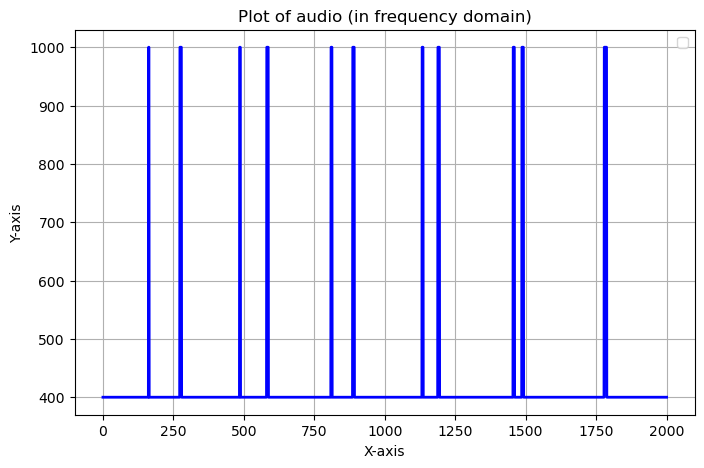

In [218]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 2000,2000)  
y = vec[0] 

# Plot the vector
plt.figure(figsize=(8, 5))
plt.plot(x, y, color='b', linewidth=2)
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.title("Plot of audio (in frequency domain)")
plt.legend()
plt.grid()
plt.show()


In [219]:
import librosa
import librosa.display
import IPython.display as ipd

audio_path = "./audio_only/audio_only_ID_1.wav" 
y, sr = librosa.load(audio_path, sr=None) 

# Listen to the audio
ipd.Audio(y, rate=sr)


# Checking for audio_only_ID_2.wav

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


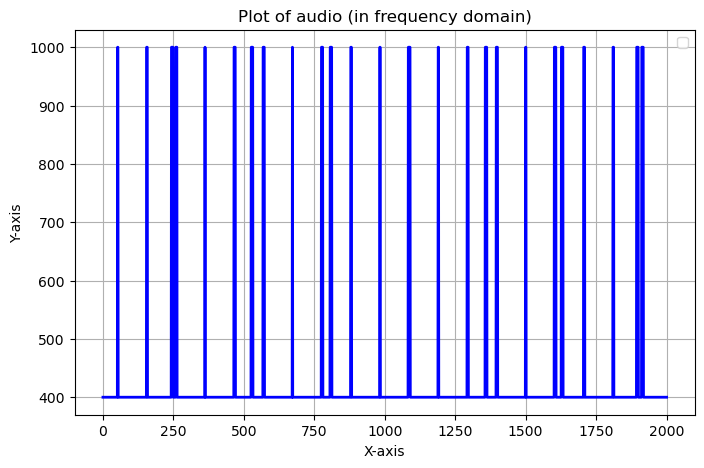

In [221]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 2000,2000)  
y = vec[1] 

# Plot the vector
plt.figure(figsize=(8, 5))
plt.plot(x, y, color='b', linewidth=2)
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.title("Plot of audio (in frequency domain)")
plt.legend()
plt.grid()
plt.show()


In [222]:
import librosa
import librosa.display
import IPython.display as ipd

audio_path = "./audio_only/audio_only_ID_2.wav" 
y, sr = librosa.load(audio_path, sr=None) 

# Listen to the audio
ipd.Audio(y, rate=sr)


In [223]:
audio_feat = vec

In [224]:
def binary_thresholding(vec):
    ret = vec
    # print (vec)
    for i in range (len(vec)):
        for j in range (len(vec[i])):
            # print (vec[i][j])
            if int(vec[i][j])>500:
                ret[i][j]=1
            else:
                ret[i][j]=0
    return ret

In [225]:
audio_feat = binary_thresholding(vec)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


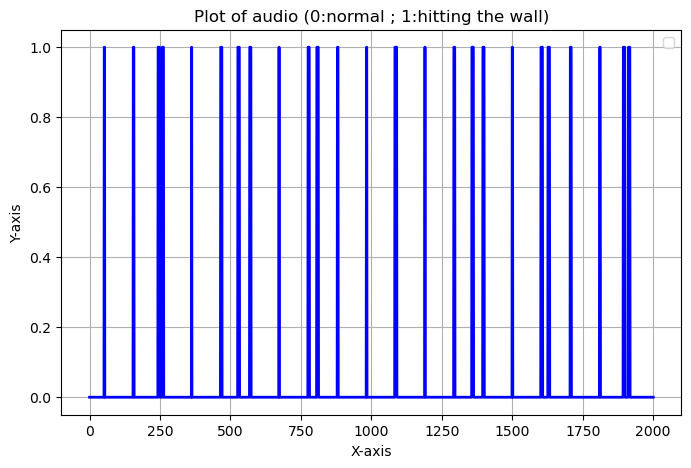

In [237]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 2000,2000)  
y = audio_feat[1] 

# Plot the vector
plt.figure(figsize=(8, 5))
plt.plot(x, y, color='b', linewidth=2)
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.title("Plot of audio (0:normal ; 1:hitting the wall)")
plt.legend()
plt.grid()
plt.show()


## ```audio_feat``` is a binary matrix of 45 x 2000 dimensions containing hit or miss info

# Video Preprocessing with same 100 fps for a perfect synchronisation

In [254]:
import os
import cv2
from tqdm import tqdm

def create_video_frames_dataset(video_folder='./video_only',
                               output_base='./video_frames',
                               target_fps=100):
    """
    Simple sequential video frame extractor with progress tracking
    """
    if not os.path.exists(video_folder):
        return f"Error: Folder '{video_folder}' not found"
    
    os.makedirs(output_base, exist_ok=True)
    video_files = [f for f in os.listdir(video_folder) if f.lower().endswith('.mp4')]
    
    if not video_files:
        return "No MP4 files found"
    
    results = []
    for file_name in tqdm(video_files, desc="Processing Videos"):
        video_path = os.path.join(video_folder, file_name)
        video_name = os.path.splitext(file_name)[0]
        output_folder = os.path.join(output_base, video_name)
        os.makedirs(output_folder, exist_ok=True)
        
        try:
            cap = cv2.VideoCapture(video_path)
            if not cap.isOpened():
                results.append(f"{file_name}: Failed to open")
                continue
            
            # Calculate frame timing
            orig_fps = cap.get(cv2.CAP_PROP_FPS)
            total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            duration = total_frames / orig_fps
            target_frames = int(duration * target_fps)
            
            saved_count = 0
            for frame_idx in range(target_frames):
                timestamp = (frame_idx / target_fps) * 1000
                cap.set(cv2.CAP_PROP_POS_MSEC, timestamp)
                ret, frame = cap.read()
                
                if ret:
                    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
                    cv2.imwrite(
                        os.path.join(output_folder, f"frame_{frame_idx:06d}.png"),
                        gray
                    )
                    saved_count += 1
            
            results.append(f"{file_name}: Saved {saved_count} frames")
            
        except Exception as e:
            results.append(f"{file_name}: Error - {str(e)}")
            
        finally:
            if 'cap' in locals() and cap.isOpened():
                cap.release()
    
    # Generate final report
    success = sum(1 for r in results if "Saved" in r)
    return (
        f"Processed {len(video_files)} videos\n"
        f"Success: {success}\n"
        f"Errors: {len(video_files)-success}\n"
        "Details:\n" + "\n".join(results)
    )

if __name__ == '__main__':
    print(create_video_frames_dataset())


Processing Videos: 100%|████████████████████████████████████████████| 45/45 [16:19<00:00, 21.77s/it]

Processed 45 videos
Success: 45
Errors: 0
Details:
video_only_ID_1.mp4: Saved 2000 frames
video_only_ID_10.mp4: Saved 2000 frames
video_only_ID_11.mp4: Saved 2000 frames
video_only_ID_12.mp4: Saved 2000 frames
video_only_ID_13.mp4: Saved 2000 frames
video_only_ID_14.mp4: Saved 2000 frames
video_only_ID_15.mp4: Saved 2000 frames
video_only_ID_16.mp4: Saved 2000 frames
video_only_ID_17.mp4: Saved 2000 frames
video_only_ID_18.mp4: Saved 2000 frames
video_only_ID_19.mp4: Saved 2000 frames
video_only_ID_2.mp4: Saved 2000 frames
video_only_ID_20.mp4: Saved 2000 frames
video_only_ID_21.mp4: Saved 2000 frames
video_only_ID_22.mp4: Saved 2000 frames
video_only_ID_23.mp4: Saved 2000 frames
video_only_ID_24.mp4: Saved 2000 frames
video_only_ID_25.mp4: Saved 2000 frames
video_only_ID_26.mp4: Saved 2000 frames
video_only_ID_27.mp4: Saved 2000 frames
video_only_ID_28.mp4: Saved 2000 frames
video_only_ID_29.mp4: Saved 2000 frames
video_only_ID_3.mp4: Saved 2000 frames
video_only_ID_30.mp4: Saved 2000

In [260]:
import cv2
import numpy as np

# Load the image in grayscale mode
image_path = './video_frames(100fps)/video_only_ID_1/frame_000000.png'  # Change to your image file path
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if img is None:
    print("Error: Image not found!")
else:
    # Apply binary thresholding
    # Pixels greater than threshold_value are set to max_value, others are set to 0.
    threshold_value = 127
    max_value = 255
    ret, binary_img = cv2.threshold(img, threshold_value, max_value, cv2.THRESH_BINARY)
    
    avg_intensity = np.mean(binary_img)
    print("Average pixel intensity of binary image:", avg_intensity)
    
    # # Optionally, display the images
    # cv2.imshow("Original Image", img)
    # cv2.imshow("Binary Thresholded Image", binary_img)
    cv2.waitKey(0)
    cv2.destroyAllWindows()


Average pixel intensity of binary image: 251.54646508487653


### The above analysis gave me a hint that avg pixel intensity changes when ball is in contact with the wall. So, we can extract it as a feature for each frame.

In [286]:
import cv2
import numpy as np
img_feat = []
for i in range(1,46):
    print (f"loading img{i}...")
    for j in range(2000):
        image_path = f"./video_frames(100fps)/video_only_ID_{i}/frame_{j:06d}.png"
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            print("Error: Image not found!")
        else:
            inverted_img = cv2.bitwise_not(img)
            threshold_value = 127
            max_value = 255
            ret, binary_img = cv2.threshold(inverted_img, threshold_value, max_value, cv2.THRESH_BINARY)
            avg_intensity = np.mean(binary_img)
            img_feat.append(avg_intensity)
print (img_feat)           

loading img1...
loading img2...
loading img3...
loading img4...
loading img5...
loading img6...
loading img7...
loading img8...
loading img9...
loading img10...
loading img11...
loading img12...
loading img13...
loading img14...
loading img15...
loading img16...
loading img17...
loading img18...
loading img19...
loading img20...
loading img21...
loading img22...
loading img23...
loading img24...
loading img25...
loading img26...
loading img27...
loading img28...
loading img29...
loading img30...
loading img31...
loading img32...
loading img33...
loading img34...
loading img35...
loading img36...
loading img37...
loading img38...
loading img39...
loading img40...
loading img41...
loading img42...
loading img43...
loading img44...
loading img45...
[3.453534915123457, 3.453534915123457, 3.453534915123457, 3.455584490740741, 3.455584490740741, 3.453534915123457, 3.453534915123457, 3.453534915123457, 3.453534915123457, 3.453534915123457, 3.455584490740741, 3.453534915123457, 3.4535349151234

In [340]:
# print (type(img_feat))
tmp = np.array(img_feat)
tmp_img = tmp.reshape(45, 2000)
tmp_aud = np.array(audio_feat)
# print (tmp_aud[0])
tmp = []
for i in range (45):
    tmp.append(tmp_aud[i])
tmp_aud = np.array(tmp)

print (type(tmp_aud))
print (type(tmp_img))
print ((tmp_aud).shape)
print ((tmp_img).shape)

np.savetxt('image_feat.csv', tmp_img, delimiter=',', fmt='%f')
np.savetxt('audio_feat.csv', tmp_aud, delimiter=',', fmt='%f')
print("NumPy arrays saved to as .csv")

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(45, 2000)
(45, 2000)
NumPy arrays saved to as .csv


In [342]:
audio_feat = tmp_aud
img_feat = tmp_img

In [362]:
epsilon = 0.01  

# row_max = np.max(img_feat, axis=1, keepdims=True)
# print (row_max)
# Apply condition: Set to 1 if value < max - epsilon, else 0
result = np.where(img_feat < (3.45 - epsilon), 1, 0)
img_feat_binary = result
# for i in range(2000):
#     print (result[0][i])

In [366]:
audio_feat_binary = audio_feat

In [370]:
# Compute L2 distance for each row in A against all rows in B
dists = np.linalg.norm(img_feat_binary[:, np.newaxis] - audio_feat_binary, axis=2)  # Shape (5,7)

# Find the minimum distance for each row of A
min_dist_indices = np.argmin(dists, axis=1)  # Indices of closest rows in B
min_dists = np.min(dists, axis=1)  # Minimum distances

# Result array: store index and distance of the closest row in B for each row in A
result = np.column_stack((min_dist_indices+1, min_dists))

print("Distance Matrix:\n", dists)
print("Result (Index, Min Distance):\n", result)

Distance Matrix:
 [[15.77973384 17.17556404 12.9614814  ... 16.64331698 16.15549442
  16.70329309]
 [26.96293753 27.40437921 28.35489376 ... 27.87471973 27.76688675
  27.83882181]
 [12.88409873 14.14213562 14.93318452 ... 13.7113092  13.6381817
  14.07124728]
 ...
 [12.16552506 13.85640646 14.6628783  ... 13.03840481 12.64911064
  13.41640786]
 [16.         16.55294536 18.02775638 ... 16.97056275 16.4924225
  16.97056275]
 [27.01851217 26.68332813 27.03701167 ... 26.94438717 26.41968963
  26.75817632]]
Result (Index, Min Distance):
 [[40.         11.5758369 ]
 [ 1.         26.96293753]
 [35.          7.93725393]
 [10.          8.30662386]
 [11.          9.8488578 ]
 [37.         32.41913015]
 [ 6.          9.53939201]
 [32.         15.3622915 ]
 [39.          8.66025404]
 [16.          9.2736185 ]
 [13.         10.        ]
 [ 2.         35.38361203]
 [42.          9.16515139]
 [16.          9.79795897]
 [24.          9.48683298]
 [12.          8.66025404]
 [41.          8.        ]
 [

In [374]:
print (dists[0])

[15.77973384 17.17556404 12.9614814  15.65247584 18.11077028 16.73320053
 17.91647287 15.93737745 16.73320053 16.70329309 16.94107435 13.6381817
 17.8325545  16.34013464 17.34935157 16.85229955 15.45962483 15.55634919
 15.19868415 16.94107435 15.49193338 17.05872211 16.58312395 17.54992877
 15.65247584 18.38477631 15.5241747  16.673332   16.34013464 18.35755975
 15.55634919 16.40121947 16.673332   15.77973384 16.37070554 18.11077028
 16.85229955 18.13835715 15.84297952 11.5758369  15.87450787 16.15549442
 16.64331698 16.15549442 16.70329309]


In [376]:
print (dists[1])

[26.96293753 27.40437921 28.35489376 27.47726333 27.85677655 27.5317998
 28.86173938 27.92848009 27.92848009 27.62245463 28.3019434  28.0713377
 27.96426291 28.54820485 28.54820485 28.14249456 27.76688675 27.78488798
 27.62245463 27.91057147 27.49545417 27.94637722 27.65863337 27.60434748
 27.83882181 28.21347196 27.69476485 27.96426291 27.69476485 27.94637722
 27.78488798 27.98213716 28.03569154 28.01785145 27.45906044 27.96426291
 27.89265136 27.98213716 27.91057147 28.17800561 28.0713377  27.58622845
 27.87471973 27.76688675 27.83882181]
